<a href="https://colab.research.google.com/github/ekinerdgn/Heart-Failure-Risk-Prediction-Using-Ensemble-Machine-Learning-Algorithms/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('heart.csv')
print("Dataset successfully loaded! Total rows:", len(df))

print("\n=== MISSINGNESS TABLE ===")
# Create the missingness table
missing_table = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_table)

Dataset successfully loaded! Total rows: 918

=== MISSINGNESS TABLE ===
                Missing Count  Percentage (%)
Age                         0             0.0
Sex                         0             0.0
ChestPainType               0             0.0
RestingBP                   0             0.0
Cholesterol                 0             0.0
FastingBS                   0             0.0
RestingECG                  0             0.0
MaxHR                       0             0.0
ExerciseAngina              0             0.0
Oldpeak                     0             0.0
ST_Slope                    0             0.0
HeartDisease                0             0.0


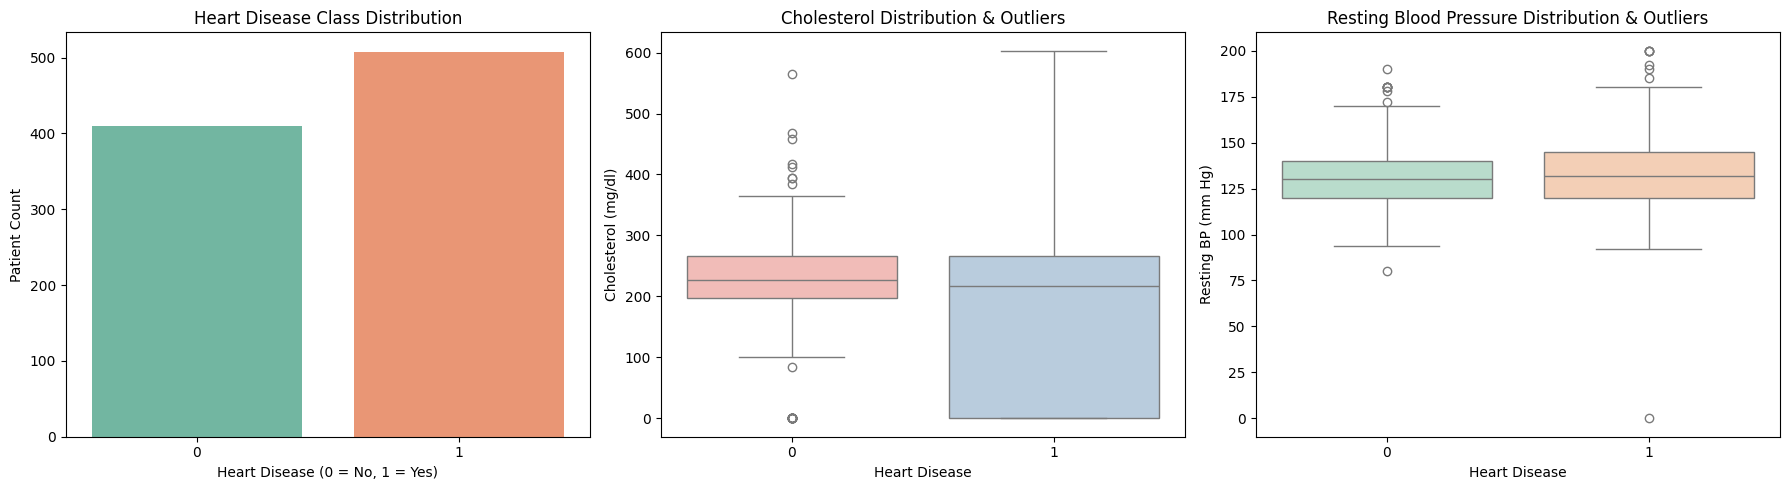

In [4]:
# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Class Distribution (Heart Disease: Yes/No)
sns.countplot(x='HeartDisease', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Heart Disease Class Distribution')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Patient Count')

# Plot B: Box Plot for Cholesterol
sns.boxplot(y='Cholesterol', x='HeartDisease', data=df, ax=axes[1], palette='Pastel1')
axes[1].set_title('Cholesterol Distribution & Outliers')
axes[1].set_xlabel('Heart Disease')
axes[1].set_ylabel('Cholesterol (mg/dl)')

# Plot C: Box Plot for Resting Blood Pressure (RestingBP)
sns.boxplot(y='RestingBP', x='HeartDisease', data=df, ax=axes[2], palette='Pastel2')
axes[2].set_title('Resting Blood Pressure Distribution & Outliers')
axes[2].set_xlabel('Heart Disease')
axes[2].set_ylabel('Resting BP (mm Hg)')

plt.tight_layout()


plt.savefig('eda_boxplots.png', dpi=300)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Separate features (X) and target variable (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# 2. Split the dataset into 80% Training and 20% Testing
# We use stratify=y to ensure the class distribution is identical in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Identify numerical and categorical features automatically
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Define the preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Combine transformers into a single preprocessor block to prevent data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("=== DATA DIVISION & PIPELINE SUMMARY ===")
print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape:  {X_test.shape}")
print("\nNumerical features to be scaled:", numeric_features)
print("Categorical features to be encoded:", categorical_features)
print("\nData leakage protection layer successfully established")

=== DATA DIVISION & PIPELINE SUMMARY ===
Training set features shape: (734, 11)
Testing set features shape:  (184, 11)

Numerical features to be scaled: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical features to be encoded: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Data leakage protection layer successfully established


In [6]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Define the 5-Fold Stratified Cross-Validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define the 4 models
models = {
    'Logistic Regression (Baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (Baseline)': DecisionTreeClassifier(random_state=42),
    'Random Forest (Ensemble)': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost (Ensemble)': XGBClassifier(scale_pos_weight=1, random_state=42, eval_metric='logloss')
}


scoring_metrics = ['accuracy', 'recall', 'f1', 'roc_auc']

print("=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===")

# 3. Loop through models and evaluate within the leakage-free pipeline
results_summary = []
for name, model in models.items():
    # Wrap preprocessor and model together to guarantee strict data separation
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring_metrics)

    # Calculate means of the evaluation metrics
    mean_accuracy = cv_results['test_accuracy'].mean() * 100
    mean_recall = cv_results['test_recall'].mean() * 100
    mean_f1 = cv_results['test_f1'].mean() * 100
    mean_auc = cv_results['test_roc_auc'].mean() * 100

    results_summary.append({
        'Model': name,
        'Accuracy (%)': round(mean_accuracy, 2),
        'Recall (%)': round(mean_recall, 2),
        'F1-Score (%)': round(mean_f1, 2),
        'AUC-ROC (%)': round(mean_auc, 2)
    })

# 4. Display the clean performance dataframe
df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ===
                         Model  Accuracy (%)  Recall (%)  F1-Score (%)  AUC-ROC (%)
Logistic Regression (Baseline)         85.02       87.69         86.69        92.48
      Decision Tree (Baseline)         79.02       80.05         80.91        78.91
      Random Forest (Ensemble)         85.70       89.66         87.46        92.89
            XGBoost (Ensemble)         85.29       87.20         86.75        91.95


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression # Needed for defining pipeline_lr
from sklearn.tree import DecisionTreeClassifier     # Needed for defining pipeline_dt
from sklearn.ensemble import RandomForestClassifier # Needed for defining pipeline_rf
from xgboost import XGBClassifier                   # Needed for defining pipeline_xgb
from sklearn.pipeline import Pipeline               # Needed for defining pipelines

# Define and fit pipelines for each model
# Re-using the classifier parameters from the cross-validation cell


pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression(max_iter=1000, random_state=42))])
pipeline_lr.fit(X_train, y_train)

pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', DecisionTreeClassifier(random_state=42))])
pipeline_dt.fit(X_train, y_train)


pipeline_rf = final_pipeline

pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', XGBClassifier(scale_pos_weight=1, random_state=42, eval_metric='logloss'))])
pipeline_xgb.fit(X_train, y_train)


models_dict = {
    "Logistic Regression": pipeline_lr,
    "Decision Tree": pipeline_dt,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

print("--- INDEPENDENT TEST SET METRICS (N=184) ---")
print(f"{'Classifier Model':<25} | {'Accuracy':<8} | {'Precision':<9} | {'F1-Score':<8} | {'Recall':<6}")
print("-" * 68)

for model_name, pipeline_model in models_dict.items():

    y_pred_test = pipeline_model.predict(X_test)


    acc = accuracy_score(y_test, y_pred_test) * 100
    prec = precision_score(y_test, y_pred_test) * 100
    f1 = f1_score(y_test, y_pred_test) * 100
    rec = recall_score(y_test, y_pred_test) * 100

    print(f"{model_name:<25} | {acc:.2f}%   | {prec:.2f}%    | {f1:.2f}%   | {rec:.2f}%")

--- INDEPENDENT TEST SET METRICS (N=184) ---
Classifier Model          | Accuracy | Precision | F1-Score | Recall
--------------------------------------------------------------------
Logistic Regression       | 88.59%   | 87.16%    | 90.05%   | 93.14%
Decision Tree             | 79.35%   | 81.37%    | 81.37%   | 81.37%
Random Forest             | 90.22%   | 88.89%    | 91.43%   | 94.12%
XGBoost                   | 87.50%   | 89.11%    | 88.67%   | 88.24%


=== FINAL TEST SET CONFUSION MATRIX ===


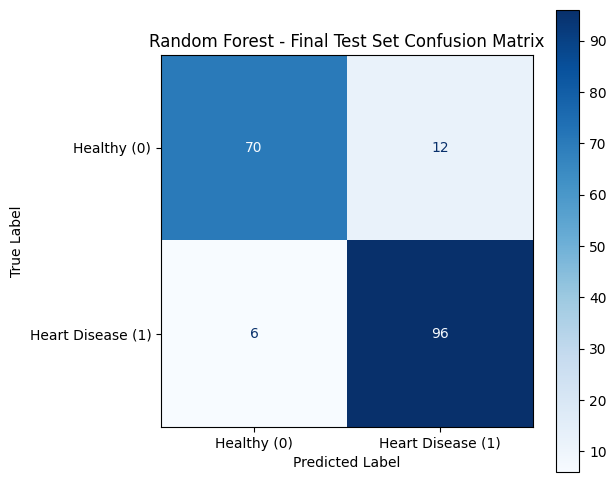

                   precision    recall  f1-score   support

      Healthy (0)       0.92      0.85      0.89        82
Heart Disease (1)       0.89      0.94      0.91       102

         accuracy                           0.90       184
        macro avg       0.90      0.90      0.90       184
     weighted avg       0.90      0.90      0.90       184



In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Re-define our champion Random Forest pipeline with class balancing
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# 2. Train the pipeline on the full training data
final_pipeline.fit(X_train, y_train)

# 3. Predict the independent final test set
y_pred = final_pipeline.predict(X_test)

# 4. Generate and plot the Confusion Matrix
print("=== FINAL TEST SET CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Heart Disease (1)'])

# Styling the plot professionally for the report
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest - Final Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')


plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# 5. Print the detailed classification report
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Heart Disease (1)']))